In [ ]:
#Q5

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical

# Load dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize data
x_train, x_test = x_train / 255.0, x_test / 255.0

# Convert labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Build CNN model
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(10, activation='softmax'))

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(x_train, y_train, epochs=10, batch_size=64)

# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.3604 - loss: 1.7309
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.4821 - loss: 1.4379
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.5264 - loss: 1.3230
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.5545 - loss: 1.2467
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.5772 - loss: 1.1941
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.5937 - loss: 1.1438
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.6053 - loss: 1.1073
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 58ms/step - accuracy: 0.6236 - loss: 1.0626
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 52ms/step - accuracy: 0.6300 - loss: 1.0381
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.6436 - loss: 0.9948
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6799 - loss: 0.9324
Test Accuracy: 0.6798999905586243


<IPython.core.display.Javascript object>

Captured file: photo.jpg


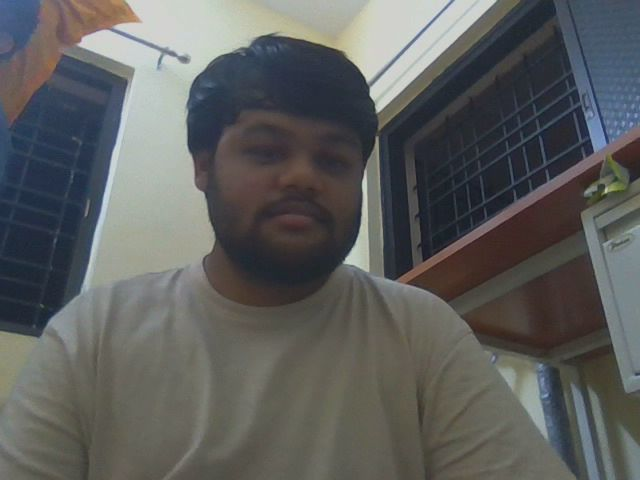

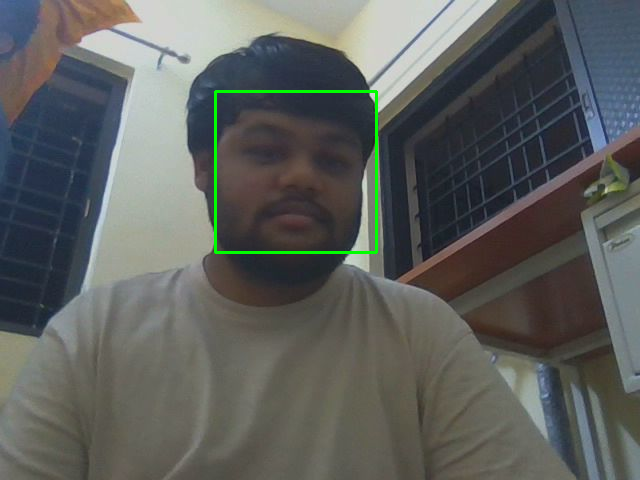

Faces detected: 1


In [11]:
# Install OpenCV
!pip install opencv-python-headless

# Imports
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode
import os

# Download Haar Cascade
!wget -q https://github.com/opencv/opencv/raw/master/data/haarcascades/haarcascade_frontalface_default.xml

# Load classifier
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# Check if loaded properly
if face_cascade.empty():
    raise Exception("Haar Cascade not loaded!")

# Webcam capture function
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)

    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

# Capture image
filename = take_photo()
print("Captured file:", filename)

# Check file exists
if not os.path.exists(filename):
    raise Exception("Image not captured properly.")

# Read image
img = cv2.imread(filename)

if img is None:
    raise Exception("Image not loaded properly.")

# Show captured image (debug)
cv2_imshow(img)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Improve contrast (VERY IMPORTANT)
gray = cv2.equalizeHist(gray)

# Reduce noise
gray = cv2.GaussianBlur(gray, (5, 5), 0)

# Face detection (tuned parameters)
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=3,
    minSize=(40, 40)
)

# Draw bounding boxes
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x,y), (x+w, y+h), (0,255,0), 2)

# Show output
cv2_imshow(img)

# Result
print(f"Faces detected: {len(faces)}")

In [13]:
#Q8

# Install required libraries
!pip install nltk scikit-learn

# Imports
import nltk
import pandas as pd
import numpy as np
import re

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Download only stopwords (no punkt needed now)
nltk.download('stopwords')

# Sample dataset (replace with IMDB/Twitter if needed)
data = {
    'text': [
        "I love this movie",
        "This film was terrible",
        "Amazing acting and story",
        "Worst movie ever",
        "I enjoyed the film",
        "It was boring and slow",
        "Absolutely fantastic experience",
        "Not worth watching",
        "Great direction and acting",
        "Very disappointing film"
    ],
    'label': [1,0,1,0,1,0,1,0,1,0]  # 1 = Positive, 0 = Negative
}

df = pd.DataFrame(data)

# Preprocessing (NO punkt issue)
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    tokens = re.findall(r'\b\w+\b', text)   # regex tokenizer
    filtered = [word for word in tokens if word not in stop_words]
    return " ".join(filtered)

# Apply preprocessing
df['clean_text'] = df['text'].apply(preprocess)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model (Naive Bayes)
model = MultinomialNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Test with custom input
sample = ["This movie was amazing and wonderful"]
sample_clean = [preprocess(sample[0])]
sample_vec = vectorizer.transform(sample_clean)

prediction = model.predict(sample_vec)

print("\nCustom Input:", sample[0])
print("Predicted Sentiment:", "Positive" if prediction[0] == 1 else "Negative")

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Custom Input: This movie was amazing and wonderful
Predicted Sentiment: Positive


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
#Q9

# Install required libraries
!pip install scikit-learn imbalanced-learn pandas

# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

# -------------------------------
# 1. LOAD DATASET
# -------------------------------

# Example dataset (replace with your CSV)
data = {
    'api_call_1': [1,0,1,0,1,0,1,0,1,0],
    'api_call_2': [0,1,0,1,0,1,0,1,0,1],
    'api_call_3': [1,1,0,0,1,1,0,0,1,0],
    'label':      [1,0,1,0,1,0,1,0,1,0]  # 1=Malware, 0=Benign
}

df = pd.DataFrame(data)

# -------------------------------
# 2. PREPROCESSING
# -------------------------------

X = df.drop('label', axis=1)
y = df['label']

# -------------------------------
# 3. HANDLE IMBALANCE (SMOTE)
# -------------------------------

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", np.bincount(y))
print("After SMOTE:", np.bincount(y_resampled))

# -------------------------------
# 4. TRAIN-TEST SPLIT
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# -------------------------------
# 5. MODEL TRAINING
# -------------------------------

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 6. PREDICTION
# -------------------------------

y_pred = model.predict(X_test)

# -------------------------------
# 7. EVALUATION
# -------------------------------

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Before SMOTE: [5 5]
After SMOTE: [5 5]

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



Dataset Shape: (330, 4)
    duration   src_bytes   dst_bytes  true_label
0  54.967142  417.100499  360.559089           0
1  48.617357  443.981896  226.226774           0
2  56.476885  574.729361  369.568474           0
3  65.230299  561.037027  408.451029           0
4  47.658466  497.909841  333.074792           0

Missing Values:
 duration      0
src_bytes     0
dst_bytes     0
true_label    0
dtype: int64

Detection Summary:
anomaly
0    297
1     33
Name: count, dtype: int64

Confusion Matrix:
 [[297   3]
 [  0  30]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       300
           1       0.91      1.00      0.95        30

    accuracy                           0.99       330
   macro avg       0.95      0.99      0.97       330
weighted avg       0.99      0.99      0.99       330



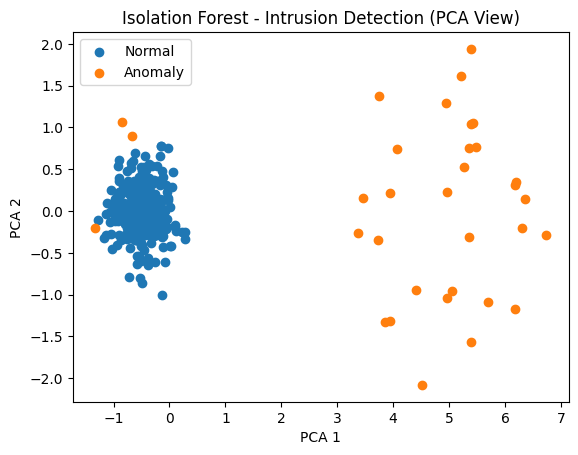

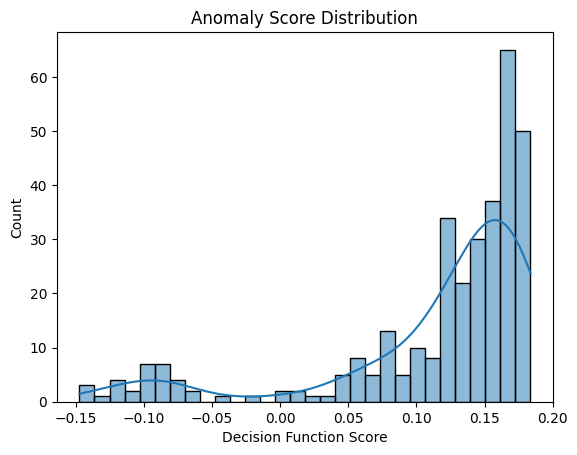


Top 5 Most Suspicious Records:
       duration    src_bytes    dst_bytes  true_label  anomaly     score  \
304  100.638587  1749.651832  1488.784354           1        1 -0.147302   
307  198.118618  1024.586916   960.968224           1        1 -0.142562   
326  106.735060  1950.863562  1357.576104           1        1 -0.141331   
316  196.299200  1426.181302  1408.036218           1        1 -0.133638   
302  183.213418  1973.488969  1078.316079           1        1 -0.122049   

         pca1      pca2  
304  5.217115  1.614260  
307  4.512934 -2.080936  
326  5.400403  1.939503  
316  6.172458 -1.175905  
302  6.199854  0.350285  


In [15]:
#Q10

# ============================================
# 1. INSTALL & IMPORT LIBRARIES
# ============================================
!pip install scikit-learn pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================
# 2. DATASET (SIMULATED NETWORK TRAFFIC)
# Replace this with NSL-KDD CSV if available
# ============================================

np.random.seed(42)

# Simulated NORMAL traffic
normal = pd.DataFrame({
    'duration': np.random.normal(50, 10, 300),
    'src_bytes': np.random.normal(500, 100, 300),
    'dst_bytes': np.random.normal(300, 80, 300)
})

# Simulated ANOMALY traffic (intrusions)
anomaly = pd.DataFrame({
    'duration': np.random.uniform(100, 200, 30),
    'src_bytes': np.random.uniform(1000, 2000, 30),
    'dst_bytes': np.random.uniform(800, 1500, 30)
})

# Combine dataset
df = pd.concat([normal, anomaly], ignore_index=True)

# Add label (for evaluation only)
df['true_label'] = [0]*len(normal) + [1]*len(anomaly)  # 0=Normal, 1=Attack

print("Dataset Shape:", df.shape)
print(df.head())

# ============================================
# 3. DATA PREPROCESSING
# ============================================

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Feature selection
features = ['duration', 'src_bytes', 'dst_bytes']
X = df[features]

# Normalize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================
# 4. TRAIN ISOLATION FOREST MODEL
# ============================================

model = IsolationForest(
    n_estimators=200,        # more trees = better detection
    contamination=0.1,       # expected anomaly %
    random_state=42
)

model.fit(X_scaled)

# ============================================
# 5. PREDICTION
# ============================================

df['anomaly'] = model.predict(X_scaled)
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})  # convert: 0=Normal, 1=Anomaly

# Anomaly score (lower = more abnormal)
df['score'] = model.decision_function(X_scaled)

print("\nDetection Summary:")
print(df['anomaly'].value_counts())

# ============================================
# 6. EVALUATION (OPTIONAL BUT GOOD FOR MARKS)
# ============================================

from sklearn.metrics import classification_report, confusion_matrix

print("\nConfusion Matrix:\n", confusion_matrix(df['true_label'], df['anomaly']))

print("\nClassification Report:\n", classification_report(df['true_label'], df['anomaly']))

# ============================================
# 7. VISUALIZATION (IMPORTANT FOR REPORT)
# ============================================

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

plt.figure()

# Plot normal points
plt.scatter(df[df['anomaly']==0]['pca1'],
            df[df['anomaly']==0]['pca2'],
            label='Normal')

# Plot anomalies
plt.scatter(df[df['anomaly']==1]['pca1'],
            df[df['anomaly']==1]['pca2'],
            label='Anomaly')

plt.title("Isolation Forest - Intrusion Detection (PCA View)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()

# ============================================
# 8. ANOMALY SCORE DISTRIBUTION
# ============================================

plt.figure()
sns.histplot(df['score'], bins=30, kde=True)
plt.title("Anomaly Score Distribution")
plt.xlabel("Decision Function Score")
plt.show()

# ============================================
# 9. TOP ANOMALIES (FOR ANALYSIS)
# ============================================

print("\nTop 5 Most Suspicious Records:")
print(df.sort_values(by='score').head())